# Analisis Exploratorio de Datos (EDA) Completo
## Motor de Recomendacion Turistica TUI - TFM UCM 2025

Este notebook realiza un analisis exhaustivo de la calidad de todos los datos del proyecto:

1. **Calidad de datos**: Valores nulos, duplicados e inconsistencias
2. **Distribuciones y variables relevantes**
3. **Patrones, outliers y relaciones entre variables**
4. **Visualizaciones**: Media, mediana, propuestas para sustituir valores o descartar registros

### Fuentes de datos analizadas:

| Fuente | Tipo | Descripcion |
|--------|------|-------------|
| Base de datos SQLite | BD | Resenas, clima, indicadores, destinos, paquetes, usuarios, interacciones |
| clima_todos_los_destinos.csv | CSV | Datos climaticos historicos |
| conectividad_y_pasajeros_2025.csv | CSV | Conectividad aerea y pasajeros |
| seguridad_y_sanidad_banco_mundial.csv | CSV | Indicadores de seguridad y sanidad |

In [23]:

import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Rutas
BASE_DIR = Path(r'D:\Master\TrabajoFinalUCM\TFM')
DB_PATH = BASE_DIR / 'data' / 'tui_recomendador.db'
CSV_CLIMA = BASE_DIR / 'data' / 'clima_todos_los_destinos.csv'
CSV_CONECTIVIDAD = BASE_DIR / 'data' / 'conectividad_y_pasajeros_2025.csv'
CSV_SEGURIDAD = BASE_DIR / 'data' / 'seguridad_y_sanidad_banco_mundial.csv'

# Funcion auxiliar para consultas
def query(sql, db=DB_PATH):
    conn = sqlite3.connect(str(db))
    df = pd.read_sql_query(sql, conn)
    conn.close()
    return df

def get_tables():
    return query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")

print(f'Base de datos: {DB_PATH} ({DB_PATH.stat().st_size / (1024*1024):.1f} MB)')
print(f'Tablas disponibles:')
tables = get_tables()
for _, row in tables.iterrows():
    n = query(f"SELECT COUNT(*) as n FROM [{row['name']}]")['n'].iloc[0]
    print(f'  - {row["name"]}: {n:,} registros')

Base de datos: D:\Master\TrabajoFinalUCM\TFM\data\tui_recomendador.db (55.9 MB)
Tablas disponibles:
  - clima_destinos: 1,638 registros
  - conectividad_destinos: 39 registros
  - customer_bookings: 149,941 registros
  - destinos_caracteristicas: 39 registros
  - embeddings_meta: 0 registros
  - experiencias: 5,850 registros
  - experiencias_reales: 0 registros
  - indicadores_destino: 3,342 registros
  - interacciones: 0 registros
  - paquetes: 0 registros
  - paquetes_versiones: 0 registros
  - resenas: 37,960 registros
  - reviews_dataset: 52,172 registros
  - seguridad_destinos: 39 registros
  - usuarios: 0 registros


---
## 1. CALIDAD DE DATOS: Valores Nulos, Duplicados e Inconsistencias



Reseñas

In [24]:
# Cargamos la tabla de resenas
df_resenas = query("SELECT * FROM resenas")
print(f'Total registros: {len(df_resenas):,}')
print(f'Columnas: {list(df_resenas.columns)}')
print(f'\n--- Tipos de datos ---')
print(df_resenas.dtypes)

# Valores nulos
print(f'\n--- Valores nulos por columna ---')
null_counts = df_resenas.isnull().sum()
null_pct = (null_counts / len(df_resenas) * 100).round(2)
null_df = pd.DataFrame({'Nulos': null_counts, 'Porcentaje (%)': null_pct})
null_df = null_df[null_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(null_df)

# Duplicados
dup_total = df_resenas.duplicated().sum()
print(f'\n--- Duplicados exactos: {dup_total} ({dup_total/len(df_resenas)*100:.2f}%) ---')

# Duplicados por texto
if 'texto_original' in df_resenas.columns:
    dup_texto = df_resenas['texto_original'].duplicated().sum()
    print(f'Textos duplicados: {dup_texto} ({dup_texto/len(df_resenas)*100:.2f}%)')

Total registros: 37,960
Columnas: ['id_resena', 'id_paquete', 'destino_nombre', 'fuente', 'texto_original', 'idioma', 'puntuacion', 'fecha_publicacion', 'url_fuente', 'fecha_extraccion']

--- Tipos de datos ---
id_resena               str
id_paquete           object
destino_nombre          str
fuente                  str
texto_original          str
idioma                  str
puntuacion           object
fecha_publicacion       str
url_fuente              str
fecha_extraccion        str
dtype: object

--- Valores nulos por columna ---
                   Nulos  Porcentaje (%)
id_paquete         37960          100.00
puntuacion         37960          100.00
fecha_publicacion  24354           64.16

--- Duplicados exactos: 0 (0.00%) ---
Textos duplicados: 0 (0.00%)


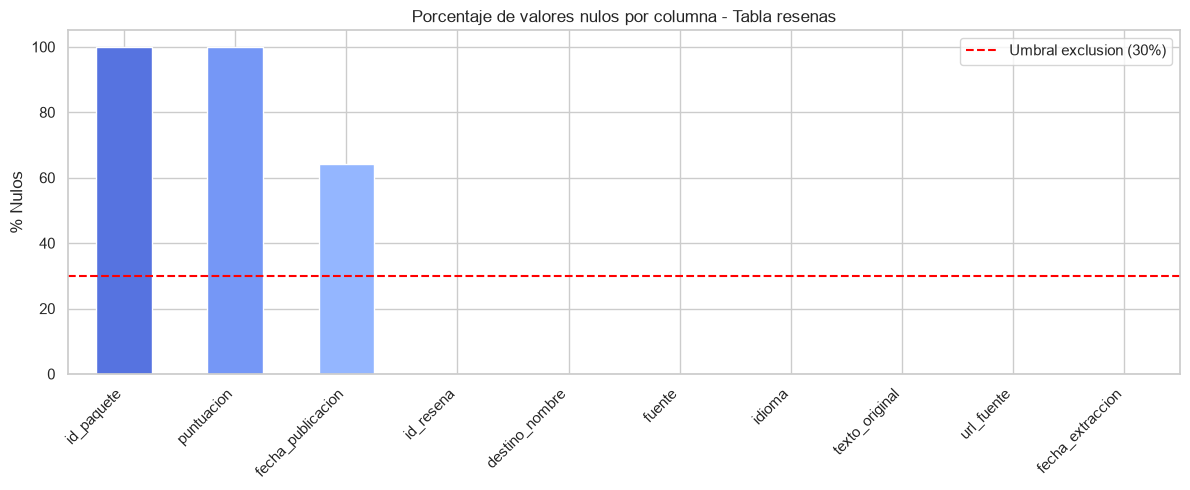


Propuesta: Columnas con >30% de nulos deben evaluarse para exclusion o imputacion.


In [25]:
# Visualizacion: Porcentaje de nulos por columna en resenas
fig, ax = plt.subplots(figsize=(12, 5))
null_all = (df_resenas.isnull().sum() / len(df_resenas) * 100).sort_values(ascending=False)
null_all.plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', len(null_all)))
ax.set_title('Porcentaje de valores nulos por columna - Tabla resenas')
ax.set_ylabel('% Nulos')
ax.axhline(y=30, color='red', linestyle='--', label='Umbral exclusion (30%)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nPropuesta: Columnas con >30% de nulos deben evaluarse para exclusion o imputacion.')

Clima destinos 

In [26]:
df_clima_db = query("SELECT * FROM clima_destinos")
print(f'Total registros: {len(df_clima_db):,}')
print(f'Columnas: {list(df_clima_db.columns)}')

# Valores nulos
print(f'\n--- Valores nulos ---')
null_clima = df_clima_db.isnull().sum()
null_pct_clima = (null_clima / len(df_clima_db) * 100).round(2)
print(pd.DataFrame({'Nulos': null_clima, '%': null_pct_clima})[null_clima > 0])

# Duplicados
dup_clima = df_clima_db.duplicated().sum()
print(f'\nDuplicados exactos: {dup_clima}')

# Consistencia: rango de temperaturas
if 'temperatura_media' in df_clima_db.columns:
    temp_stats = df_clima_db['temperatura_media'].describe()
    print(f'\n--- Estadisticas de temperatura_media ---')
    print(temp_stats)
    anomalias = df_clima_db[(df_clima_db['temperatura_media'] < -20) | (df_clima_db['temperatura_media'] > 55)]
    print(f'Valores anomalos (< -20 o > 55): {len(anomalias)}')

Total registros: 1,638
Columnas: ['id', 'destino_nombre', 'latitud', 'longitud', 'anio', 'mes', 'temp_media', 'temp_max', 'temp_min', 'precipitacion_mm', 'horas_sol', 'fecha_extraccion', 'temp_agua', 'humedad_pct', 'dias_lluvia']

--- Valores nulos ---
             Nulos      %
temp_agua     1410  86.08
humedad_pct   1350  82.42
dias_lluvia   1350  82.42

Duplicados exactos: 0


Indicadores_destino

In [27]:
df_indicadores = query("SELECT * FROM indicadores_destino")
print(f'Total registros: {len(df_indicadores):,}')
print(f'Columnas: {list(df_indicadores.columns)}')

# Valores nulos
print(f'\n--- Valores nulos ---')
null_ind = df_indicadores.isnull().sum()
null_pct_ind = (null_ind / len(df_indicadores) * 100).round(2)
print(pd.DataFrame({'Nulos': null_ind, '%': null_pct_ind})[null_ind > 0])

# Duplicados
dup_ind = df_indicadores.duplicated().sum()
print(f'\nDuplicados exactos: {dup_ind}')

# Inconsistencias: valores negativos donde no deberia haber
if 'valor' in df_indicadores.columns:
    negativos = df_indicadores[df_indicadores['valor'] < 0]
    print(f'\nValores negativos en columna valor: {len(negativos)}')
    if len(negativos) > 0:
        print(negativos[['destino_nombre', 'tipo_indicador', 'valor']].head(10))

Total registros: 3,342
Columnas: ['id_indicador', 'destino_nombre', 'fuente', 'tipo_indicador', 'valor', 'anio', 'mes', 'fecha_extraccion']

--- Valores nulos ---
Empty DataFrame
Columns: [Nulos, %]
Index: []

Duplicados exactos: 0

Valores negativos en columna valor: 0


destinos caracteristicas

In [28]:
df_destinos = query("SELECT * FROM destinos_caracteristicas")
print(f'Total registros: {len(df_destinos):,}')
print(f'Columnas: {list(df_destinos.columns)}')

# Valores nulos
print(f'\n--- Valores nulos ---')
null_dest = df_destinos.isnull().sum()
null_pct_dest = (null_dest / len(df_destinos) * 100).round(2)
null_report = pd.DataFrame({'Nulos': null_dest, '%': null_pct_dest})
print(null_report[null_dest > 0].sort_values('%', ascending=False))

# Duplicados por nombre de destino
if 'destino_nombre' in df_destinos.columns:
    dup_dest = df_destinos['destino_nombre'].duplicated().sum()
    print(f'\nDestinos duplicados por nombre: {dup_dest}')

Total registros: 39
Columnas: ['id', 'destino_nombre', 'pais', 'zona_geografica', 'latitud', 'longitud', 'descripcion_wikipedia', 'categorias_principales', 'poblacion_estimada', 'tiene_playa', 'tiene_patrimonio_unesco', 'es_isla', 'clima_predominante', 'idioma_principal', 'moneda', 'accesibilidad_estimada', 'sensibilidad_ambiental', 'nivel_saturacion_conocido', 'fecha_extraccion']

--- Valores nulos ---
                       Nulos     %
descripcion_wikipedia      1  2.56

Destinos duplicados por nombre: 0


Archivos CSV  compartidos por mati


In [29]:
# --- CSV: clima_todos_los_destinos.csv ---
print('=' * 60)
print('ARCHIVO: clima_todos_los_destinos.csv')
print('=' * 60)
df_clima_csv = pd.read_csv(CSV_CLIMA)
print(f'Registros: {len(df_clima_csv):,}')
print(f'Columnas: {list(df_clima_csv.columns)}')
print(f'\nNulos:')
print(df_clima_csv.isnull().sum()[df_clima_csv.isnull().sum() > 0])
print(f'\nDuplicados: {df_clima_csv.duplicated().sum()}')

print('\n')

# --- CSV: conectividad_y_pasajeros_2025.csv ---
print('=' * 60)
print('ARCHIVO: conectividad_y_pasajeros_2025.csv')
print('=' * 60)
df_conect = pd.read_csv(CSV_CONECTIVIDAD)
print(f'Registros: {len(df_conect):,}')
print(f'Columnas: {list(df_conect.columns)}')
print(f'\nNulos:')
print(df_conect.isnull().sum()[df_conect.isnull().sum() > 0])
print(f'\nDuplicados: {df_conect.duplicated().sum()}')

print('\n')

# --- CSV: seguridad_y_sanidad_banco_mundial.csv ---
print('=' * 60)
print('ARCHIVO: seguridad_y_sanidad_banco_mundial.csv')
print('=' * 60)
df_seguridad = pd.read_csv(CSV_SEGURIDAD)
print(f'Registros: {len(df_seguridad):,}')
print(f'Columnas: {list(df_seguridad.columns)}')
print(f'\nNulos:')
null_seg = df_seguridad.isnull().sum()
print(null_seg[null_seg > 0])
print(f'\nDuplicados: {df_seguridad.duplicated().sum()}')

ARCHIVO: clima_todos_los_destinos.csv
Registros: 1,140
Columnas: ['lugar', 'year_month', 'temp_media_aire_c', 'temp_media_agua_c', 'precipitacion_total_mm', 'dias_lluvia', 'horas_sol_totales', 'humedad_media_pct']

Nulos:
temp_media_agua_c    156
dtype: int64

Duplicados: 0


ARCHIVO: conectividad_y_pasajeros_2025.csv
Registros: 212
Columnas: ['grupo', 'termino_original', 'iata_destino', 'rutas_directas_ES', 'rutas_directas_UK', 'rutas_directas_DE', 'vuelos_semanales_estimados', 'asientos_semanales_ofertados', 'pasajeros_semanales_estimados', 'pasajeros_anuales_estimados']

Nulos:
Series([], dtype: int64)

Duplicados: 0


ARCHIVO: seguridad_y_sanidad_banco_mundial.csv
Registros: 173
Columnas: ['iso', 'pais', 'camas_hospital_1000hab', 'tasa_homicidios_100mil']

Nulos:
camas_hospital_1000hab    32
tasa_homicidios_100mil    17
dtype: int64

Duplicados: 0


 calidad de datos

In [30]:
# Resumen consolidado de calidad
resumen_calidad = []

datasets = {
    'resenas (BD)': df_resenas,
    'clima_destinos (BD)': df_clima_db,
    'indicadores_destino (BD)': df_indicadores,
    'destinos_caracteristicas (BD)': df_destinos,
    'clima_csv': df_clima_csv,
    'conectividad_csv': df_conect,
    'seguridad_csv': df_seguridad,
}

for nombre, df in datasets.items():
    total = len(df)
    nulos_total = df.isnull().sum().sum()
    celdas_total = total * len(df.columns)
    pct_nulos = (nulos_total / celdas_total * 100) if celdas_total > 0 else 0
    duplicados = df.duplicated().sum()
    resumen_calidad.append({
        'Dataset': nombre,
        'Registros': total,
        'Columnas': len(df.columns),
        'Celdas nulas': nulos_total,
        '% Nulos': round(pct_nulos, 2),
        'Duplicados': duplicados
    })

df_resumen = pd.DataFrame(resumen_calidad)
print('RESUMEN DE CALIDAD DE DATOS')
print('=' * 80)
print(df_resumen.to_string(index=False))

RESUMEN DE CALIDAD DE DATOS
                      Dataset  Registros  Columnas  Celdas nulas  % Nulos  Duplicados
                 resenas (BD)      37960        10        100274    26.42           0
          clima_destinos (BD)       1638        15          4110    16.73           0
     indicadores_destino (BD)       3342         8             0     0.00           0
destinos_caracteristicas (BD)         39        19             1     0.13           0
                    clima_csv       1140         8           156     1.71           0
             conectividad_csv        212        10             0     0.00           0
                seguridad_csv        173         4            49     7.08           0


---
## . DISTRIBUCIONES Y VARIABLES RELEVANTES

Analizamos las distribuciones de las variables mas importantes para el sistema de recomendacion.

### Distribucion de resenas por fuente e idioma

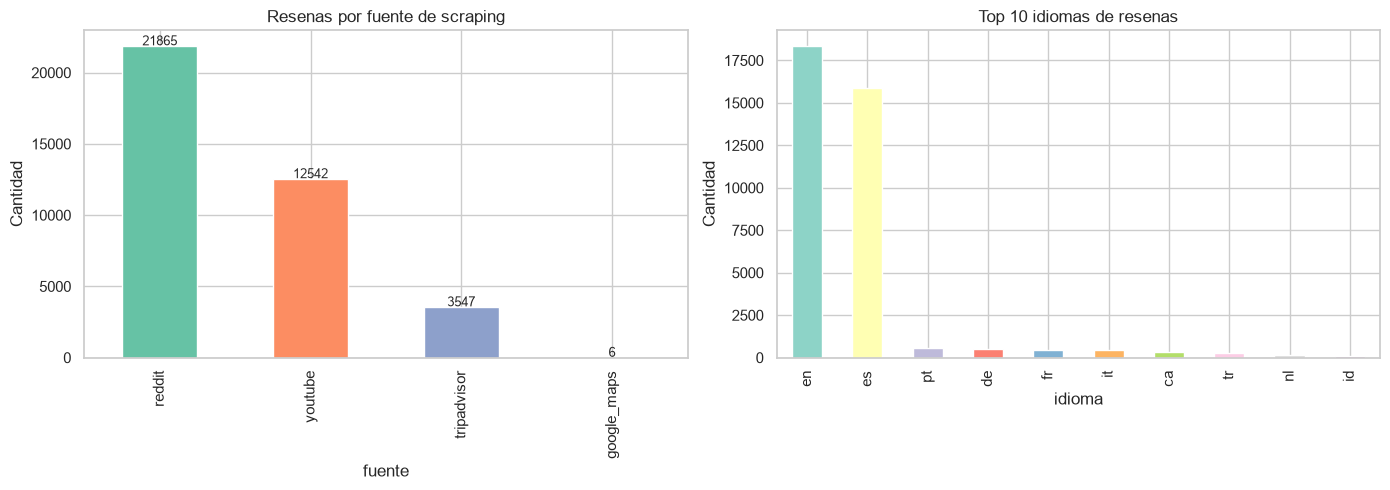

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por fuente
if 'fuente' in df_resenas.columns:
    fuente_counts = df_resenas['fuente'].value_counts()
    fuente_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(fuente_counts)))
    axes[0].set_title('Resenas por fuente de scraping')
    axes[0].set_ylabel('Cantidad')
    for i, v in enumerate(fuente_counts.values):
        axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

# Por idioma
if 'idioma' in df_resenas.columns:
    idioma_counts = df_resenas['idioma'].value_counts().head(10)
    idioma_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set3', len(idioma_counts)))
    axes[1].set_title('Top 10 idiomas de resenas')
    axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

###  Distribucion de resenas por destino

In [ ]:
if 'destino_nombre' in df_resenas.columns:
    dest_counts = df_resenas['destino_nombre'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 20 destinos
    dest_counts.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Top 20 destinos con mas resenas')
    axes[0].set_xlabel('Numero de resenas')
    axes[0].invert_yaxis()
    
    # Distribucion (histograma del numero de resenas por destino)
    axes[1].hist(dest_counts.values, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1].axvline(dest_counts.median(), color='blue', linestyle='--', label=f'Mediana: {dest_counts.median():.0f}')
    axes[1].axvline(dest_counts.mean(), color='red', linestyle='--', label=f'Media: {dest_counts.mean():.0f}')
    axes[1].set_title('Distribucion del numero de resenas por destino')
    axes[1].set_xlabel('Resenas por destino')
    axes[1].set_ylabel('Frecuencia')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f'\nEstadisticas de resenas por destino:')
    print(f'  Media: {dest_counts.mean():.1f}')
    print(f'  Mediana: {dest_counts.median():.1f}')
    print(f'  Desviacion estandar: {dest_counts.std():.1f}')
    print(f'  Minimo: {dest_counts.min()} ({dest_counts.idxmin()})')
    print(f'  Maximo: {dest_counts.max()} ({dest_counts.idxmax()})')
    print(f'\n  PROPUESTA: Destinos con menos de {int(dest_counts.quantile(0.1))} resenas (percentil 10)'
          f' podrian requerir enriquecimiento adicional de datos.')

###  Longitud de textos de resenas

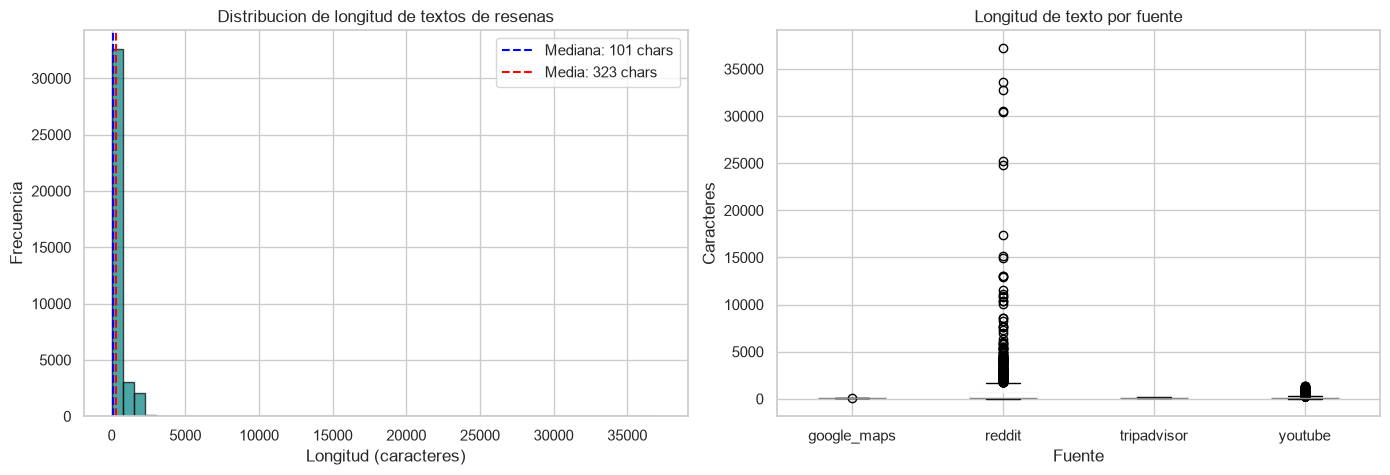


Textos con menos de 20 caracteres: 8 (0.0%)
PROPUESTA: Considerar excluir textos < 20 caracteres del calculo de embeddings.


In [ ]:
if 'texto_original' in df_resenas.columns:
    df_resenas['len_texto'] = df_resenas['texto_original'].fillna('').str.len()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma de longitud
    axes[0].hist(df_resenas['len_texto'], bins=50, color='teal', edgecolor='black', alpha=0.7)
    axes[0].axvline(df_resenas['len_texto'].median(), color='blue', linestyle='--', 
                    label=f'Mediana: {df_resenas["len_texto"].median():.0f} chars')
    axes[0].axvline(df_resenas['len_texto'].mean(), color='red', linestyle='--', 
                    label=f'Media: {df_resenas["len_texto"].mean():.0f} chars')
    axes[0].set_title('Distribucion de longitud de textos de resenas')
    axes[0].set_xlabel('Longitud (caracteres)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    
    # Boxplot por fuente
    if 'fuente' in df_resenas.columns:
        df_resenas.boxplot(column='len_texto', by='fuente', ax=axes[1])
        axes[1].set_title('Longitud de texto por fuente')
        axes[1].set_xlabel('Fuente')
        axes[1].set_ylabel('Caracteres')
        plt.suptitle('')  # Eliminar titulo automatico
    
    plt.tight_layout()
    plt.show()
    
    # Textos muy cortos (potencialmente no utiles para embeddings)
    cortos = len(df_resenas[df_resenas['len_texto'] < 20])
    print(f'\nTextos con menos de 20 caracteres: {cortos} ({cortos/len(df_resenas)*100:.1f}%)')
    print(f'PROPUESTA: Considerar excluir textos < 20 caracteres del calculo de embeddings.')

###  Indicadores por fuente y tipo

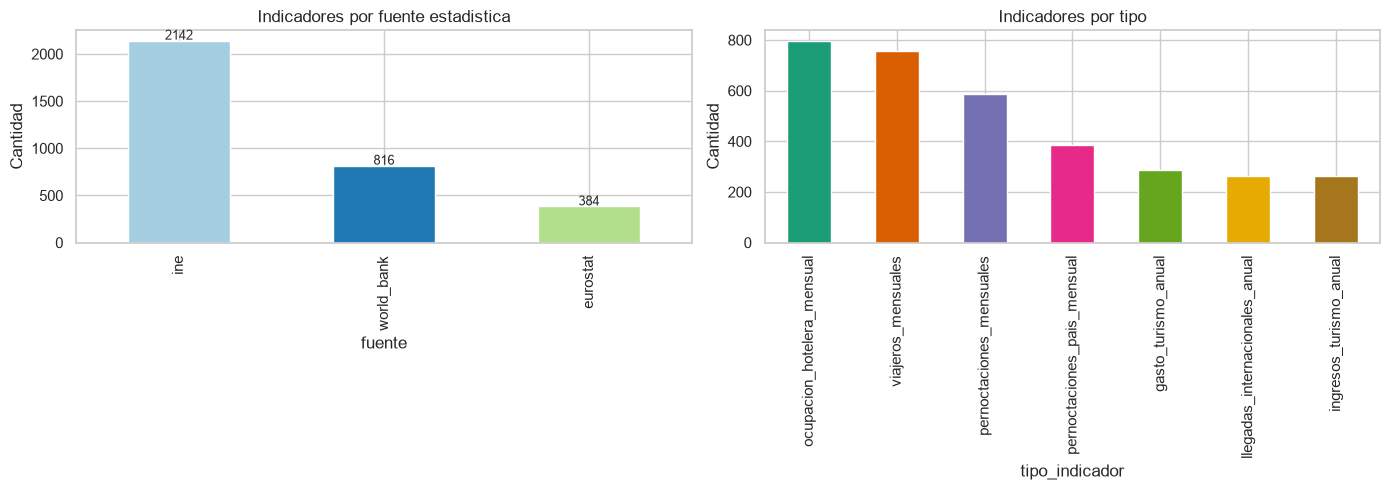

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'fuente' in df_indicadores.columns:
    fuente_ind = df_indicadores['fuente'].value_counts()
    fuente_ind.plot(kind='bar', ax=axes[0], color=sns.color_palette('Paired', len(fuente_ind)))
    axes[0].set_title('Indicadores por fuente estadistica')
    axes[0].set_ylabel('Cantidad')
    for i, v in enumerate(fuente_ind.values):
        axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

if 'tipo_indicador' in df_indicadores.columns:
    tipo_ind = df_indicadores['tipo_indicador'].value_counts()
    tipo_ind.plot(kind='bar', ax=axes[1], color=sns.color_palette('Dark2', len(tipo_ind)))
    axes[1].set_title('Indicadores por tipo')
    axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

### Datos climaticos

Estadisticas descriptivas - clima_todos_los_destinos.csv
       temp_media_aire_c  temp_media_agua_c  precipitacion_total_mm  \
count            1140.00             984.00                 1140.00   
mean               19.01              21.75                   75.66   
std                 7.20               5.39                   95.82   
min                -8.80               4.70                    0.00   
25%                13.80              17.70                   12.95   
50%                19.00              21.20                   44.55   
75%                24.80              26.20                  104.95   
max                36.90              34.70                 1105.90   

       dias_lluvia  horas_sol_totales  humedad_media_pct  
count      1140.00            1140.00            1140.00  
mean          8.78             308.06              69.87  
std           7.09              70.88              12.73  
min           0.00               4.90              14.10  
25%     

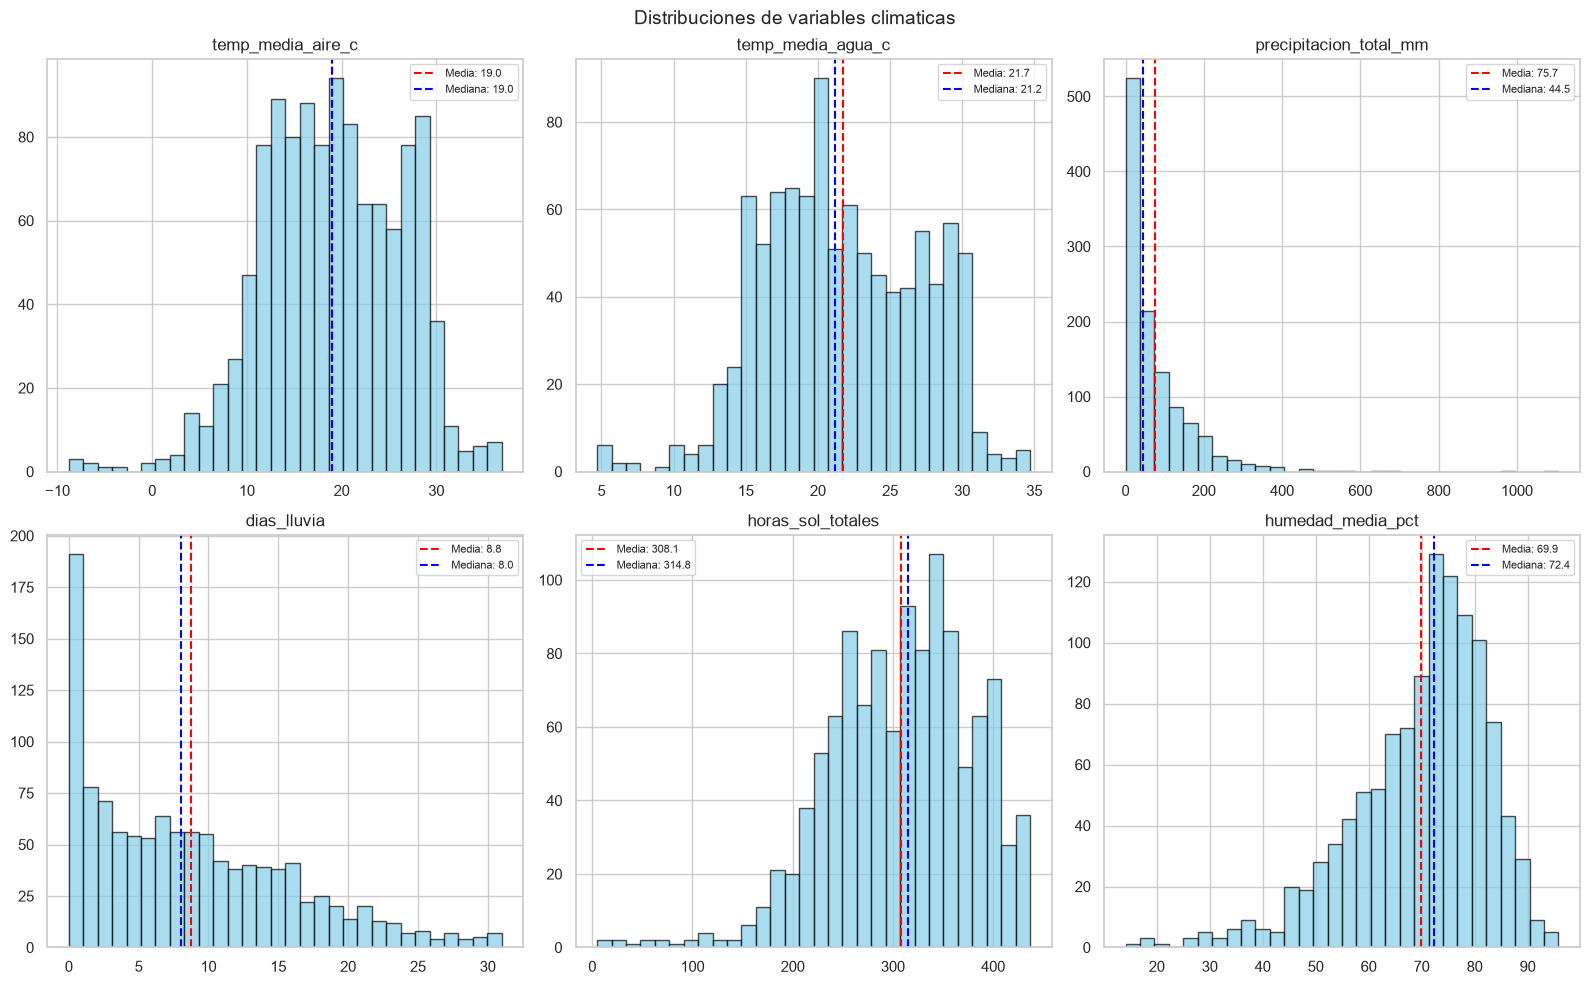

In [ ]:
# Estadisticas descriptivas del CSV de clima
print('Estadisticas descriptivas - clima_todos_los_destinos.csv')
print('=' * 60)
# Seleccionar solo columnas numericas
numeric_cols = df_clima_csv.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    print(df_clima_csv[numeric_cols].describe().round(2))
    
    # Visualizacion de distribuciones
    n_cols = min(len(numeric_cols), 6)
    if n_cols > 0:
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        for i, col in enumerate(numeric_cols[:6]):
            axes[i].hist(df_clima_csv[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            mean_val = df_clima_csv[col].mean()
            median_val = df_clima_csv[col].median()
            axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.1f}')
            axes[i].axvline(median_val, color='blue', linestyle='--', label=f'Mediana: {median_val:.1f}')
            axes[i].set_title(col)
            axes[i].legend(fontsize=8)
        # Ocultar ejes sobrantes
        for j in range(n_cols, 6):
            axes[j].set_visible(False)
        plt.suptitle('Distribuciones de variables climaticas', fontsize=14)
        plt.tight_layout()
        plt.show()

---
##  PATRONES, OUTLIERS Y RELACIONES ENTRE VARIABLES

### Deteccion de Outliers en resenas

Outliers en longitud de texto (metodo IQR):
  Limite inferior: -318
  Limite superior: 670
  Outliers detectados: 5919 (15.6%)
  - Por debajo: 0
  - Por encima: 5919


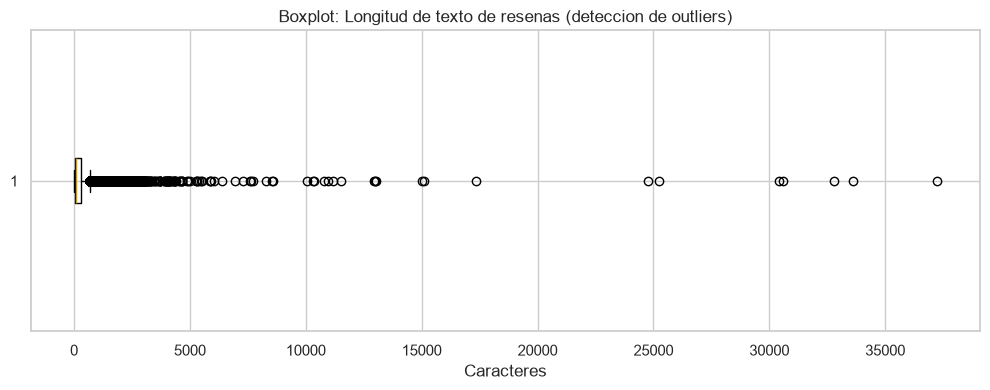


PROPUESTA: Los textos extremadamente largos (> limite superior) probablemente provienen de posts completos de Reddit/YouTube. Considerar truncar a 2000 caracteres para el calculo de embeddings.


In [ ]:
if 'len_texto' in df_resenas.columns:
    # Metodo IQR para detectar outliers
    Q1 = df_resenas['len_texto'].quantile(0.25)
    Q3 = df_resenas['len_texto'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_resenas[(df_resenas['len_texto'] < lower) | (df_resenas['len_texto'] > upper)]
    print(f'Outliers en longitud de texto (metodo IQR):')
    print(f'  Limite inferior: {lower:.0f}')
    print(f'  Limite superior: {upper:.0f}')
    print(f'  Outliers detectados: {len(outliers)} ({len(outliers)/len(df_resenas)*100:.1f}%)')
    print(f'  - Por debajo: {len(df_resenas[df_resenas["len_texto"] < lower])}')
    print(f'  - Por encima: {len(df_resenas[df_resenas["len_texto"] > upper])}')
    
    # Boxplot general
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(df_resenas['len_texto'].values, vert=False)
    ax.set_title('Boxplot: Longitud de texto de resenas (deteccion de outliers)')
    ax.set_xlabel('Caracteres')
    plt.tight_layout()
    plt.show()
    
    print('\nPROPUESTA: Los textos extremadamente largos (> limite superior) probablemente '
          'provienen de posts completos de Reddit/YouTube. Considerar truncar a 2000 caracteres '
          'para el calculo de embeddings.')

### Outliers en indicadores de destino

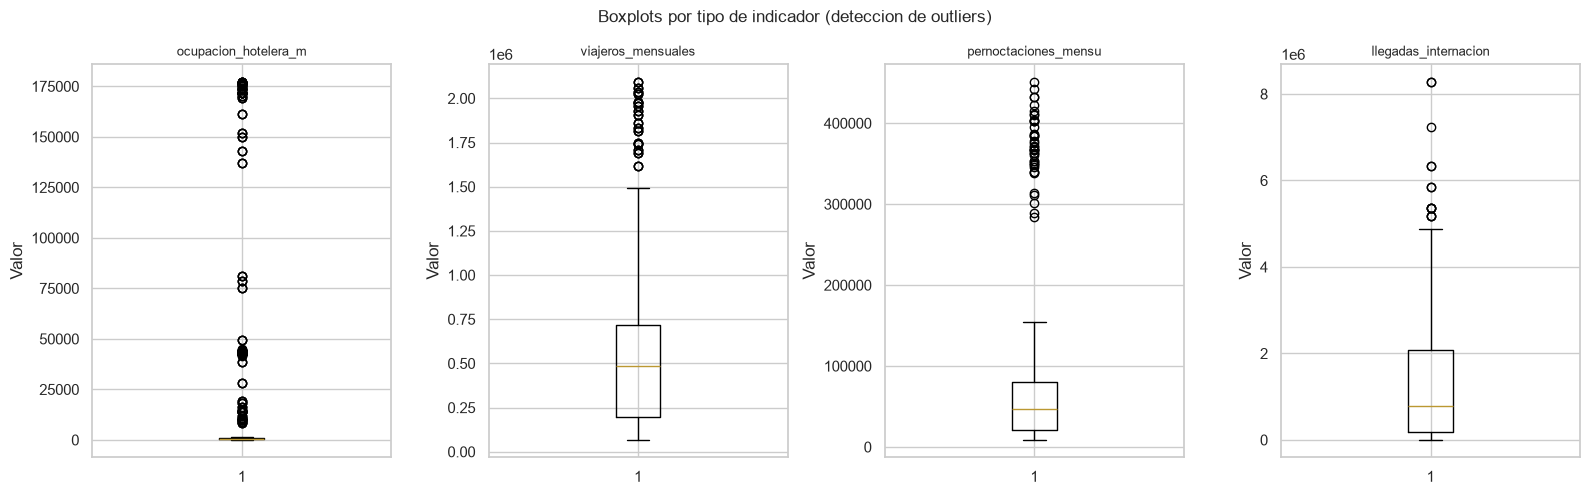


Outliers por tipo de indicador (metodo IQR):
  ocupacion_hotelera_mensual: 168 outliers
  viajeros_mensuales: 51 outliers
  pernoctaciones_mensuales: 42 outliers
  llegadas_internacionales_anual: 14 outliers
  gasto_turismo_anual: 31 outliers
  ingresos_turismo_anual: 20 outliers
  pernoctaciones_pais_mensual: 18 outliers


In [ ]:
if 'valor' in df_indicadores.columns and 'tipo_indicador' in df_indicadores.columns:
    # Outliers por tipo de indicador
    tipos = df_indicadores['tipo_indicador'].unique()
    
    fig, axes = plt.subplots(1, min(len(tipos), 4), figsize=(16, 5))
    if len(tipos) == 1:
        axes = [axes]
    
    for i, tipo in enumerate(tipos[:4]):
        subset = df_indicadores[df_indicadores['tipo_indicador'] == tipo]['valor']
        axes[i].boxplot(subset.dropna().values, vert=True)
        axes[i].set_title(tipo[:20], fontsize=9)
        axes[i].set_ylabel('Valor')
    
    plt.suptitle('Boxplots por tipo de indicador (deteccion de outliers)', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Resumen de outliers por tipo
    print('\nOutliers por tipo de indicador (metodo IQR):')
    for tipo in tipos:
        subset = df_indicadores[df_indicadores['tipo_indicador'] == tipo]['valor'].dropna()
        if len(subset) > 4:
            q1, q3 = subset.quantile(0.25), subset.quantile(0.75)
            iqr = q3 - q1
            n_outliers = len(subset[(subset < q1 - 1.5*iqr) | (subset > q3 + 1.5*iqr)])
            if n_outliers > 0:
                print(f'  {tipo}: {n_outliers} outliers')

### Correlaciones entre variables climaticas

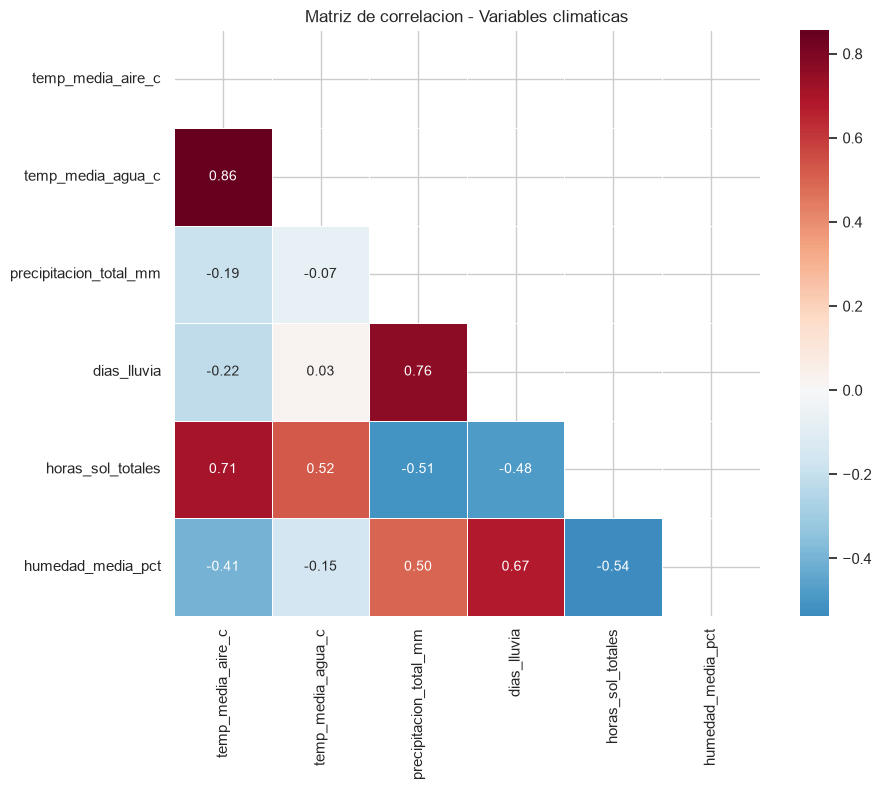

Correlaciones fuertes (|r| > 0.7):
  temp_media_aire_c <-> temp_media_agua_c: 0.855
  temp_media_aire_c <-> horas_sol_totales: 0.711
  precipitacion_total_mm <-> dias_lluvia: 0.757


In [ ]:
numeric_cols_clima = df_clima_csv.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols_clima) >= 2:
    corr_matrix = df_clima_csv[numeric_cols_clima].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, fmt='.2f')
    ax.set_title('Matriz de correlacion - Variables climaticas')
    plt.tight_layout()
    plt.show()
    
    # Correlaciones fuertes
    print('Correlaciones fuertes (|r| > 0.7):')
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            val = corr_matrix.iloc[i, j]
            if abs(val) > 0.7:
                print(f'  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {val:.3f}')

### Cobertura de destinos entre fuentes

In [ ]:
# Verificar que destinos estan presentes en cada fuente
destinos_esperados = [
    'Mallorca', 'Tenerife', 'Ibiza', 'Costa del Sol', 'Barcelona',
    'Madrid', 'Malaga', 'Sevilla', 'Valencia', 'Gran Canaria',
    'Alicante', 'Bilbao', 'San Sebastian', 'Cordoba', 'Granada',
    'Cadiz', 'Fuerteventura', 'Lanzarote', 'Menorca', 'Antalya',
    'Rodas', 'Santorini', 'Hurghada', 'Punta Cana', 'Cancun',
    'Riviera Maya', 'Dubai', 'Maldivas', 'Bali', 'Phuket',
    'Marrakech', 'Cabo Verde', 'Split', 'Creta', 'Sicilia',
    'Cerdena', 'Costa Amalfitana', 'Algarve', 'Tunez'
]

def check_coverage(df, col_name, dataset_name):
    """Verifica cobertura de destinos esperados."""
    if col_name not in df.columns:
        return None
    destinos_en_data = set(df[col_name].dropna().unique())
    presentes = [d for d in destinos_esperados if d in destinos_en_data]
    ausentes = [d for d in destinos_esperados if d not in destinos_en_data]
    return {'dataset': dataset_name, 'presentes': len(presentes), 
            'ausentes': len(ausentes), 'total': len(destinos_esperados),
            'destinos_ausentes': ausentes}

coverages = []
coverages.append(check_coverage(df_resenas, 'destino_nombre', 'resenas'))
coverages.append(check_coverage(df_clima_db, 'destino_nombre', 'clima_destinos'))
coverages.append(check_coverage(df_indicadores, 'destino_nombre', 'indicadores'))
coverages.append(check_coverage(df_destinos, 'destino_nombre', 'destinos_caract'))

print('COBERTURA DE DESTINOS ESPERADOS POR FUENTE')
print('=' * 60)
for c in coverages:
    if c:
        pct = c['presentes'] / c['total'] * 100
        print(f"  {c['dataset']:<25} {c['presentes']}/{c['total']} ({pct:.0f}%)")
        if c['ausentes'] > 0 and c['ausentes'] <= 10:
            print(f"    Ausentes: {', '.join(c['destinos_ausentes'][:5])}...")

print('\nPROPUESTA: Priorizar enriquecimiento de datos para destinos '
      'ausentes en multiples fuentes.')

COBERTURA DE DESTINOS ESPERADOS POR FUENTE
  resenas                   30/39 (77%)
    Ausentes: Malaga, Sevilla, San Sebastian, Cordoba, Cadiz...
  clima_destinos            31/39 (79%)
    Ausentes: Malaga, San Sebastian, Cordoba, Cadiz, Cancun...
  indicadores               31/39 (79%)
    Ausentes: Malaga, San Sebastian, Cordoba, Cadiz, Cancun...
  destinos_caract           31/39 (79%)
    Ausentes: Malaga, San Sebastian, Cordoba, Cadiz, Cancun...

PROPUESTA: Priorizar enriquecimiento de datos para destinos ausentes en multiples fuentes.


---
## VISUALIZACIONES Y PROPUESTAS DE TRATAMIENTO

### Comparativa Media vs Mediana por destino (resenas)

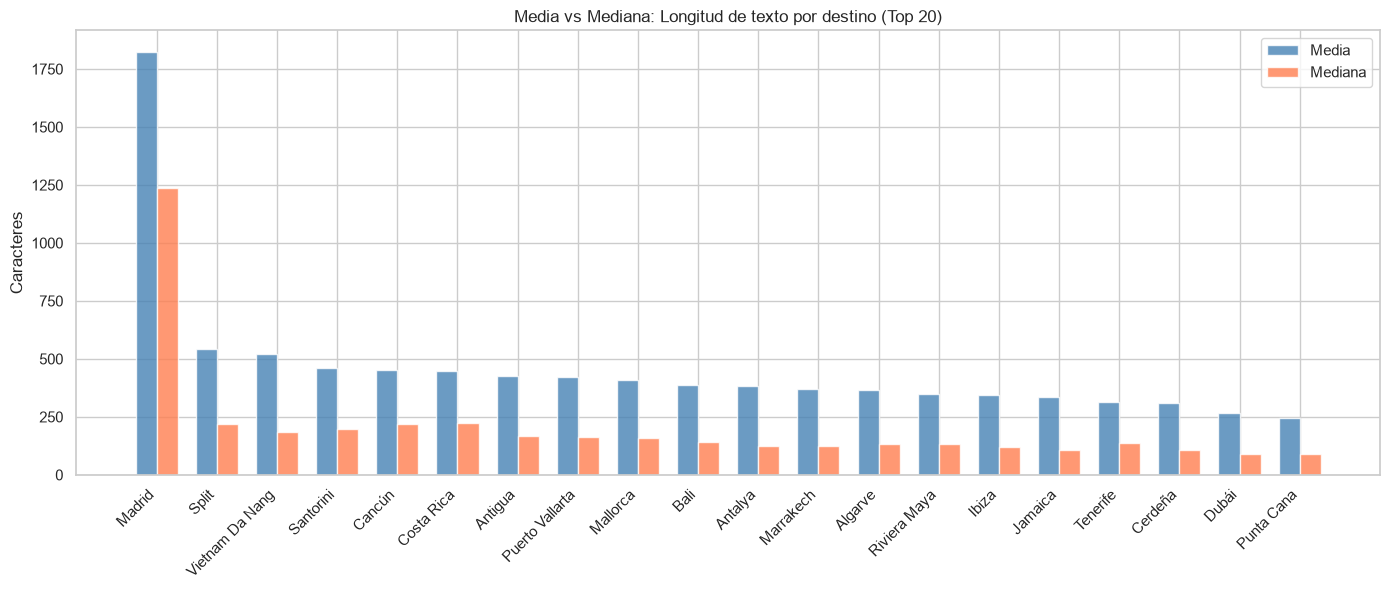

Destinos con alta diferencia Media-Mediana (sesgo positivo > 50%):
                  mean  median  diff_pct
destino_nombre                          
Split            542.0   218.0     148.6
Vietnam Da Nang  521.0   185.0     181.6
Santorini        460.0   196.0     134.7
Cancún           454.0   218.0     108.3
Costa Rica       447.0   224.0      99.6
Antigua          425.0   168.0     153.0
Puerto Vallarta  420.0   164.0     156.1
Mallorca         409.0   160.0     155.6
Bali             388.0   140.0     177.1
Antalya          384.0   123.0     212.2
Marrakech        372.0   126.0     195.2
Algarve          365.0   134.0     172.4
Riviera Maya     348.0   134.0     159.7
Ibiza            346.0   118.0     193.2
Jamaica          336.0   108.0     211.1
Tenerife         315.0   139.0     126.6
Cerdeña          310.0   107.0     189.7
Dubái            266.0    92.0     189.1
Punta Cana       246.0    92.0     167.4

PROPUESTA: Para estos destinos, la MEDIANA es mas representativa que la

In [ ]:
if 'destino_nombre' in df_resenas.columns and 'len_texto' in df_resenas.columns:
    # Media y mediana de longitud de texto por destino (top 20)
    top_destinos = df_resenas['destino_nombre'].value_counts().head(20).index
    df_top = df_resenas[df_resenas['destino_nombre'].isin(top_destinos)]
    
    stats_destino = df_top.groupby('destino_nombre')['len_texto'].agg(['mean', 'median', 'std']).round(0)
    stats_destino = stats_destino.sort_values('mean', ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    x = range(len(stats_destino))
    width = 0.35
    bars1 = ax.bar([i - width/2 for i in x], stats_destino['mean'], width, 
                   label='Media', color='steelblue', alpha=0.8)
    bars2 = ax.bar([i + width/2 for i in x], stats_destino['median'], width, 
                   label='Mediana', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(stats_destino.index, rotation=45, ha='right')
    ax.set_title('Media vs Mediana: Longitud de texto por destino (Top 20)')
    ax.set_ylabel('Caracteres')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Destinos con alta diferencia media-mediana (sesgo)
    stats_destino['diff_pct'] = ((stats_destino['mean'] - stats_destino['median']) / stats_destino['median'] * 100).round(1)
    sesgados = stats_destino[stats_destino['diff_pct'] > 50]
    if len(sesgados) > 0:
        print('Destinos con alta diferencia Media-Mediana (sesgo positivo > 50%):')
        print(sesgados[['mean', 'median', 'diff_pct']])
        print('\nPROPUESTA: Para estos destinos, la MEDIANA es mas representativa que la media.'
              ' Usar mediana para normalizar embeddings.')

### Propuestas para tratamiento de valores nulos

In [ ]:
print('PROPUESTAS PARA TRATAMIENTO DE VALORES NULOS')
print('=' * 70)
print()
print('1. RESENAS:')
print('   - puntuacion (nula): NO imputar. Muchas fuentes (Reddit, YouTube)')
print('     no tienen puntuacion numerica. Usar solo para fuentes con rating.')
print('   - fecha_publicacion (nula): Imputar con fecha de extraccion si disponible.')
print('   - texto_original (vacio): EXCLUIR del calculo de embeddings.')
print()
print('2. INDICADORES DE DESTINO:')
print('   - mes (nulo): Correcto para indicadores anuales. No requiere imputacion.')
print('   - valor (negativo): Verificar si es error o valor valido segun tipo.')
print()
print('3. CLIMA:')
print('   - Variables con <5% nulos: Imputar con interpolacion temporal.')
print('   - Variables con >30% nulos: Evaluar exclusion de la variable.')
print()
print('4. CONECTIVIDAD/SEGURIDAD:')
print('   - Valores nulos por pais: Imputar con media regional si <20% nulos.')
print('   - Si >20% nulos en un pais: Excluir ese pais del analisis.')
print()
print('UMBRAL GENERAL (segun config.yml): Si un registro tiene >30% de atributos')
print('vacios, se excluye del sistema de recomendacion (parametro exclusion_threshold).')

PROPUESTAS PARA TRATAMIENTO DE VALORES NULOS

1. RESENAS:
   - puntuacion (nula): NO imputar. Muchas fuentes (Reddit, YouTube)
     no tienen puntuacion numerica. Usar solo para fuentes con rating.
   - fecha_publicacion (nula): Imputar con fecha de extraccion si disponible.
   - texto_original (vacio): EXCLUIR del calculo de embeddings.

2. INDICADORES DE DESTINO:
   - mes (nulo): Correcto para indicadores anuales. No requiere imputacion.
   - valor (negativo): Verificar si es error o valor valido segun tipo.

3. CLIMA:
   - Variables con <5% nulos: Imputar con interpolacion temporal.
   - Variables con >30% nulos: Evaluar exclusion de la variable.

4. CONECTIVIDAD/SEGURIDAD:
   - Valores nulos por pais: Imputar con media regional si <20% nulos.
   - Si >20% nulos en un pais: Excluir ese pais del analisis.

UMBRAL GENERAL (segun config.yml): Si un registro tiene >30% de atributos
vacios, se excluye del sistema de recomendacion (parametro exclusion_threshold).


### Resumen visual consolidado

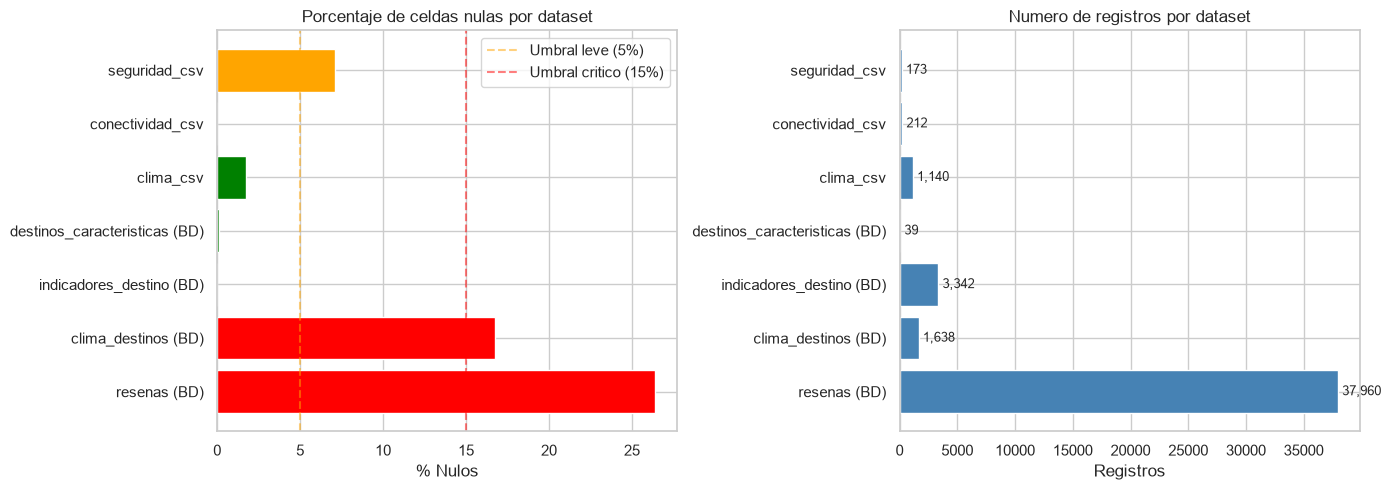

In [ ]:
# Visualizacion consolidada de calidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Porcentaje de nulos por dataset
nombres = [r['Dataset'] for r in resumen_calidad]
pct_nulos = [r['% Nulos'] for r in resumen_calidad]
colors = ['green' if p < 5 else 'orange' if p < 15 else 'red' for p in pct_nulos]
axes[0].barh(nombres, pct_nulos, color=colors)
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.5, label='Umbral leve (5%)')
axes[0].axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Umbral critico (15%)')
axes[0].set_title('Porcentaje de celdas nulas por dataset')
axes[0].set_xlabel('% Nulos')
axes[0].legend()

# Grafico 2: Registros por dataset
registros = [r['Registros'] for r in resumen_calidad]
axes[1].barh(nombres, registros, color='steelblue')
axes[1].set_title('Numero de registros por dataset')
axes[1].set_xlabel('Registros')
for i, v in enumerate(registros):
    axes[1].text(v + max(registros)*0.01, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## CONCLUSIONES 

   - Puntuacion numerica ausente en fuentes sin rating (Reddit, YouTube)
   - Distribucion desigual de resenas por destino (sesgo hacia destinos populares)
   - Textos de longitud muy variable (algunos extremadamente largos)

**propuestas de tratamiento**
   - **NO imputar** puntuaciones: usar analisis de sentimiento del texto como proxy (Javie aqui estas tu)
   - **Truncar** textos a 2000 caracteres para embeddings 
   - **Excluir** registros con texto vacio del sistema de embeddings
   - **Usar mediana** como estadistico robusto para destinos con distribuciones sesgadas
   - **Enriquecer** datos para destinos con baja cobertura

Outliers**:
   - En longitud de texto: textos >5000 caracteres son posts completos. Truncar.
   - En indicadores: valores atipicos por cambios metodologicos entre anos. Verificar.
